In [1]:
import scanpy as sc
import os
import pandas as pd
from matplotlib.path import Path
from matplotlib.patches import PathPatch

In [2]:
import h5py
import pandas as pd
from scipy import sparse
from anndata import AnnData

#file_path = '/Users/sergio/Documents/projects/insitucnv/1105_CNV.h5ad'
file_path = '/home/augusta/storage3/augusta/insituCNV/InSituCNV/Breast_cancer_Xenium5K/01_InSituCNV/data/1105_CNV.h5ad'


def load_essential_adata(path):
    with h5py.File(path, 'r') as f:
        # 1. Load Matrix (X)
        if 'X' in f:
            if isinstance(f['X'], h5py.Group):
                # Handle sparse matrix
                X = sparse.csr_matrix(
                    (f['X/data'][:], f['X/indices'][:], f['X/indptr'][:]), 
                    shape=f['X'].attrs['shape']
                )
            else:
                # Handle dense matrix
                X = f['X'][:]
        
        # 2. Load Observations (cell metadata)
        # We manually pull columns to avoid registry errors
        obs_dict = {}
        for k in f['obs'].keys():
            data = f[f'obs/{k}']
            # We only want simple datasets (columns)
            if isinstance(data, h5py.Dataset):
                val = data[:]
                # Decode if it's byte-strings
                if val.dtype.kind in {'S', 'O'}:
                    val = [v.decode('utf-8') if isinstance(v, bytes) else v for v in val]
                obs_dict[k] = val
        
        obs = pd.DataFrame(obs_dict)
        # Handle index if stored separately
        if '_index' in f['obs'].attrs:
            idx_col = f['obs'].attrs['_index']
            obs.index = obs[idx_col]
        
        # 3. Load Variables (gene names)
        var_dict = {}
        for k in f['var'].keys():
            data = f[f'var/{k}']
            if isinstance(data, h5py.Dataset):
                val = data[:]
                if val.dtype.kind in {'S', 'O'}:
                    val = [v.decode('utf-8') if isinstance(v, bytes) else v for v in val]
                var_dict[k] = val
        var = pd.DataFrame(var_dict)
        if '_index' in f['var'].attrs:
            idx_col = f['var'].attrs['_index']
            var.index = var[idx_col]

        # 4. Load Spatial Coordinates
        obsm_spatial = f['obsm/spatial'][:]

        # Build Clean AnnData
        adata = AnnData(X=X, obs=obs, var=var)
        adata.obsm['spatial'] = obsm_spatial
        return adata

# Execution
adata = load_essential_adata(file_path)
print(f"Success! Loaded {adata.n_obs} cells and {adata.n_vars} genes.")

Success! Loaded 72345 cells and 5090 genes.


In [3]:
def load_essential_adata_v2(path):
    with h5py.File(path, 'r') as f:
        # 1. Load Matrix
        X = f['X'][:] if not isinstance(f['X'], h5py.Group) else \
            sparse.csr_matrix((f['X/data'][:], f['X/indices'][:], f['X/indptr'][:]), shape=f['X'].attrs['shape'])
        
        # 2. Load OBS with Category handling
        obs_dict = {}
        for k in f['obs'].keys():
            if isinstance(f[f'obs/{k}'], h5py.Dataset):
                val = f[f'obs/{k}'][:]
                if val.dtype.kind in {'S', 'O'}:
                    val = [v.decode('utf-8') if isinstance(v, bytes) else v for v in val]
                obs_dict[k] = val
            # Handle categorical data (Leiden clusters often stored as codes + categories)
            elif isinstance(f[f'obs/{k}'], h5py.Group) and 'categories' in f[f'obs/{k}']:
                codes = f[f'obs/{k}/codes'][:]
                categories = f[f'obs/{k}/categories'][:]
                categories = [c.decode('utf-8') if isinstance(c, bytes) else c for c in categories]
                obs_dict[k] = pd.Categorical.from_codes(codes, categories)

        obs = pd.DataFrame(obs_dict)
        
        # 3. Restore the correct Index
        # AnnData usually stores the index name in the 'obs' attributes
        if '_index' in f['obs'].attrs:
            idx_name = f['obs'].attrs['_index']
            if isinstance(idx_name, bytes): idx_name = idx_name.decode('utf-8')
            if idx_name in obs.columns:
                obs.index = obs[idx_name]
                # Optional: del obs[idx_name] # Keep it clean
        
        # 4. Variables (Genes)
        var_dict = {k: (f[f'var/{k}'][:].astype(str) if f[f'var/{k}'].dtype.kind in {'S', 'O'} else f[f'var/{k}'][:]) 
                    for k in f['var'].keys() if isinstance(f[f'var/{k}'], h5py.Dataset)}
        var = pd.DataFrame(var_dict)
        if '_index' in f['var'].attrs:
            var_idx = f['var'].attrs['_index']
            if isinstance(var_idx, bytes): var_idx = var_idx.decode('utf-8')
            if var_idx in var.columns: var.index = var[var_idx]

        # 5. Spatial
        obsm_spatial = f['obsm/spatial'][:]

        adata = AnnData(X=X, obs=obs, var=var)
        adata.obsm['spatial'] = obsm_spatial
        return adata

In [4]:
# Execution
adata = load_essential_adata_v2(file_path)
print(f"Success! Loaded {adata.n_obs} cells and {adata.n_vars} genes.")

Success! Loaded 72345 cells and 5090 genes.


In [5]:
adata.obs.columns

Index(['_index', 'cell.id', 'cell_area', 'cell_id', 'cell_labels',
       'cell_type_oct25', 'cnv_leiden_res0.1', 'cnv_leiden_res0.3',
       'cnv_status', 'cnv_subclones', 'compartment', 'control_codeword_counts',
       'control_probe_counts', 'deprecated_codeword_counts',
       'genomic_control_counts', 'leiden', 'log1p_n_genes_by_counts',
       'log1p_total_counts', 'n_counts', 'n_genes_by_counts', 'nucleus_area',
       'nucleus_count', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'pct_counts_in_top_50_genes', 'region', 'sample', 'segmentation_method',
       'total_counts', 'transcript_counts', 'unassigned_codeword_counts',
       'z_level'],
      dtype='object')

/tmp/ipykernel_2362840/1865500485.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color='cnv_subclones',spot_size=20)
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


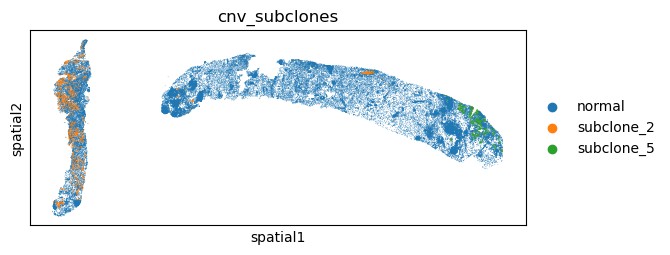

In [6]:
sc.pl.spatial(adata,color='cnv_subclones',spot_size=20)

## Pre- vs on-treatment clonal composition

This section summarizes the epithelial malignant compartment (`cell_type_oct25 == 'Epithelial'` and `cnv_subclones != 'normal'`) before the downstream niche analysis.

The plot below shows the relative epithelial subclone composition at each timepoint as stacked bars, with soft connectors between matching subclones to make the pre- to on-treatment shift easier to read.



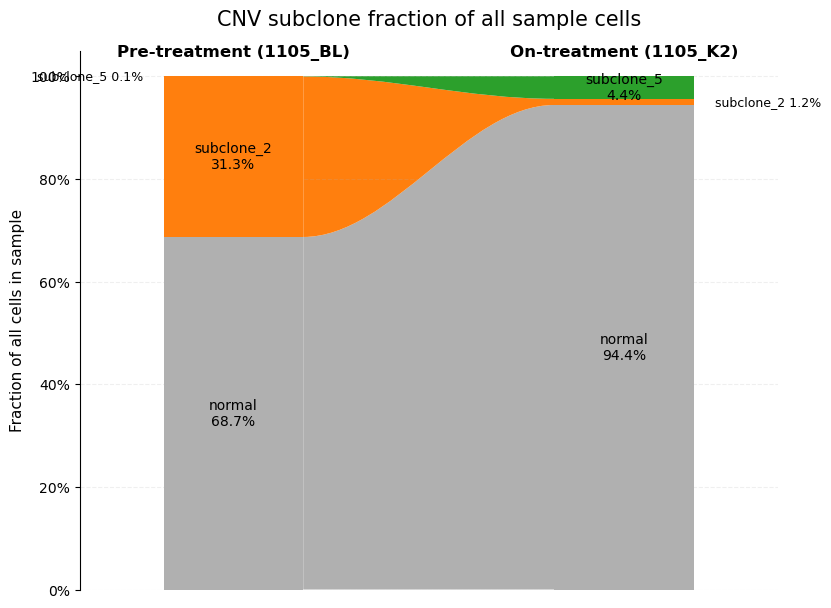

,Pre-treatment,On-treatment
cnv_subclones,,
normal,68.7%,94.4%
subclone_2,31.3%,1.2%
subclone_5,0.1%,4.4%


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from matplotlib.ticker import PercentFormatter

def infer_treatment_label(sample_name):
    sample_name = str(sample_name)
    sample_upper = sample_name.upper()
    if any(token in sample_upper for token in ['BL', 'PRE', 'BASELINE']):
        return 'Pre-treatment'
    if any(token in sample_upper for token in ['ON', 'POST', 'TX', 'TRT', 'CYCLE', 'V', 'K']):
        return 'On-treatment'
    return sample_name

def compute_stacked_positions(values_by_clone, clone_order):
    positions = {}
    y_cursor = 0.0
    for clone in clone_order:
        height = float(values_by_clone.get(clone, 0.0))
        positions[clone] = (y_cursor, y_cursor + height)
        y_cursor += height
    return positions

def get_clone_color_map(adata, clone_order):
    clone_categories = [str(x) for x in adata.obs['cnv_subclones'].cat.categories]
    raw_colors = adata.uns['cnv_subclones_colors']

    parsed_colors = []
    for c in raw_colors:
        if isinstance(c, bytes):
            parsed_colors.append(c.decode('utf-8'))
        else:
            parsed_colors.append(str(c))

    full_color_map = dict(zip(clone_categories, parsed_colors))
    return {clone: full_color_map.get(clone, '#808080') for clone in clone_order}


def add_smooth_connector(ax, x0, x1, y0_bottom, y0_top, y1_bottom, y1_top, color, alpha=1):
    dx = x1 - x0
    c = dx * 0.35

    verts = [
        (x0, y0_top),
        (x0 + c, y0_top),
        (x1 - c, y1_top),
        (x1, y1_top),

        (x1, y1_bottom),

        (x1 - c, y1_bottom),
        (x0 + c, y0_bottom),
        (x0, y0_bottom),

        (x0, y0_top),
    ]

    codes = [
        Path.MOVETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.LINETO,
        Path.CURVE4,
        Path.CURVE4,
        Path.CURVE4,
        Path.CLOSEPOLY,
    ]

    ax.add_patch(
        PathPatch(
            Path(verts, codes),
            facecolor=color,
            edgecolor='none',
            lw=0,
            alpha=alpha,
            zorder=1,
        )
    )

def plot_composition_transition(clone_comp_summary, left_title, right_title, color_map):
    clone_order = clone_comp_summary.index.tolist()
    left_values = clone_comp_summary.iloc[:, 0].to_dict()
    right_values = clone_comp_summary.iloc[:, 1].to_dict()

    left_positions = compute_stacked_positions(left_values, clone_order)
    right_positions = compute_stacked_positions(right_values, clone_order)

    fig, ax = plt.subplots(figsize=(9, 7))
    left_x0, left_x1 = 0.12, 0.32
    right_x0, right_x1 = 0.68, 0.88
    connector_x0, connector_x1 = left_x1, right_x0

    for clone in clone_order:
        left_y0, left_y1 = left_positions[clone]
        right_y0, right_y1 = right_positions[clone]
        color = color_map[clone]

        add_smooth_connector(
            ax,
            connector_x0,
            connector_x1,
            left_y0,
            left_y1,
            right_y0,
            right_y1,
            color=color,
        )

        ax.add_patch(Rectangle(
            (left_x0, left_y0),
            left_x1 - left_x0,
            left_y1 - left_y0,
            facecolor=color,
            edgecolor='none',
            linewidth=0,
            zorder=2,
        ))
        
        ax.add_patch(Rectangle(
            (right_x0, right_y0),
            right_x1 - right_x0,
            right_y1 - right_y0,
            facecolor=color,
            edgecolor='none',
            linewidth=0,
            zorder=2,
        ))

        left_mid = (left_y0 + left_y1) / 2
        right_mid = (right_y0 + right_y1) / 2
        left_value = left_values[clone]
        right_value = right_values[clone]

        if left_value >= 0.02:
            ax.text((left_x0 + left_x1) / 2, left_mid, f"{clone}\n{left_value:.1%}",
                    ha='center', va='center', fontsize=10, color='black', zorder=3)
        else:
            ax.text(left_x0 - 0.03, left_mid, f"{clone} {left_value:.1%}",
                    ha='right', va='center', fontsize=9)

        if right_value >= 0.02:
            ax.text((right_x0 + right_x1) / 2, right_mid, f"{clone}\n{right_value:.1%}",
                    ha='center', va='center', fontsize=10, color='black', zorder=3)
        else:
            ax.text(right_x1 + 0.03, right_mid, f"{clone} {right_value:.1%}",
                    ha='left', va='center', fontsize=9)

    ax.text((left_x0 + left_x1) / 2, 1.03, left_title, ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text((right_x0 + right_x1) / 2, 1.03, right_title, ha='center', va='bottom', fontsize=12, fontweight='bold')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.05)
    ax.set_xticks([])
    ax.set_ylabel('Fraction of all cells in sample', fontsize=11)
    ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
    ax.spines[['top', 'right', 'bottom']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.2)
    return fig, ax

clone_comp_df = (
    adata.obs[['sample', 'cnv_subclones']]
    .assign(
        sample=lambda df: df['sample'].astype(str),
        cnv_subclones=lambda df: df['cnv_subclones'].astype(str)
    )
    .groupby(['sample', 'cnv_subclones'])
    .size()
    .rename('n_cells')
    .reset_index()
)

total_cells_per_sample = (
    adata.obs.assign(sample=adata.obs['sample'].astype(str))
    .groupby('sample')
    .size()
)

clone_comp_df['fraction_within_sample'] = (
    clone_comp_df['n_cells'] /
    clone_comp_df['sample'].map(total_cells_per_sample)
)

samples = sorted(clone_comp_df['sample'].unique())
if len(samples) != 2:
    raise ValueError(f'Expected exactly two samples, found {len(samples)}: {samples}')

pre_sample, on_sample = samples
if infer_treatment_label(samples[0]) == 'On-treatment' and infer_treatment_label(samples[1]) == 'Pre-treatment':
    pre_sample, on_sample = samples[1], samples[0]

sample_label_map = {
    pre_sample: infer_treatment_label(pre_sample),
    on_sample: infer_treatment_label(on_sample),
}

pre_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == pre_sample]
    .set_index('cnv_subclones')['fraction_within_sample']
)
on_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == on_sample]
    .set_index('cnv_subclones')['fraction_within_sample']
)

clone_order = sorted(
    set(pre_series.index).union(on_series.index),
    key=lambda x: (-max(pre_series.get(x, 0), on_series.get(x, 0)), str(x))
)

clone_comp_summary = pd.DataFrame({
    sample_label_map[pre_sample]: pre_series.reindex(clone_order, fill_value=0.0),
    sample_label_map[on_sample]: on_series.reindex(clone_order, fill_value=0.0),
})

summary_display = clone_comp_df.copy()
summary_display['timepoint'] = summary_display['sample'].map(sample_label_map)
summary_display = summary_display.sort_values(
    ['timepoint', 'fraction_within_sample'],
    ascending=[True, False]
)
summary_display

color_map = get_clone_color_map(adata, clone_order)
color_map['normal'] = '#B0B0B0'

fig, ax = plot_composition_transition(
    clone_comp_summary,
    left_title=f"{sample_label_map[pre_sample]} ({pre_sample})",
    right_title=f"{sample_label_map[on_sample]} ({on_sample})",
    color_map=color_map,
)
ax.set_title('CNV subclone fraction of all sample cells', fontsize=15, pad=18)
plt.savefig('1105_CNV_subclone_change_BL_ontreat_all.svg')
plt.show()

clone_comp_summary.style.format('{:.1%}')



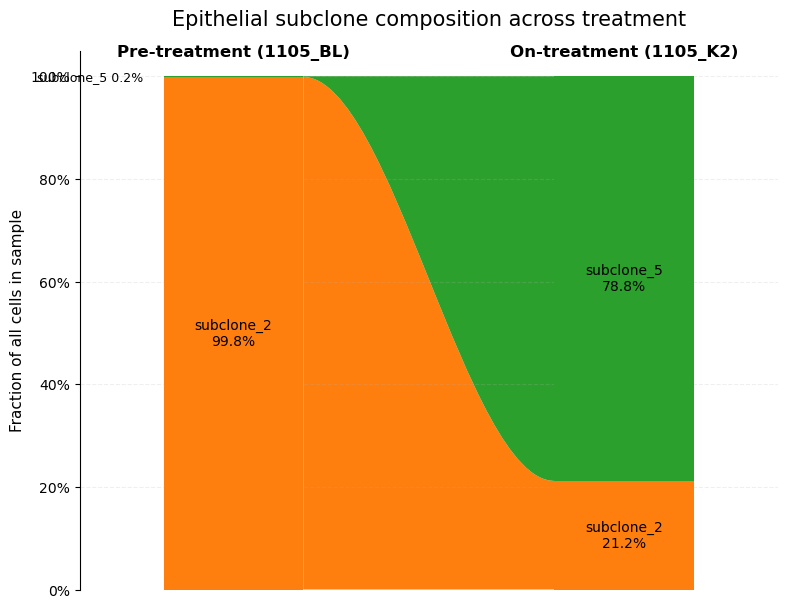

,Pre-treatment,On-treatment
cnv_subclones,,
subclone_2,100%,21%
subclone_5,0%,79%


In [16]:
malignant_mask = (
    (adata.obs['cell_type_oct25'] == 'Epithelial') &
    (adata.obs['cnv_subclones'].astype(str) != 'normal')
)

clone_comp_df = (
    adata.obs.loc[malignant_mask, ['sample', 'cnv_subclones']]
    .assign(
        cnv_subclones=lambda df: df['cnv_subclones'].astype(str),
        sample=lambda df: df['sample'].astype(str)
    )
    .groupby(['sample', 'cnv_subclones'])
    .size()
    .rename('n_cells')
    .reset_index()
)

clone_comp_df['fraction_within_malignant'] = (
    clone_comp_df.groupby('sample')['n_cells'].transform(lambda x: x / x.sum())
)

samples = sorted(clone_comp_df['sample'].unique())
if len(samples) != 2:
    raise ValueError(f'Expected exactly two samples, found {len(samples)}: {samples}')

pre_sample, on_sample = samples
if infer_treatment_label(samples[0]) == 'On-treatment' and infer_treatment_label(samples[1]) == 'Pre-treatment':
    pre_sample, on_sample = samples[1], samples[0]

sample_label_map = {
    pre_sample: infer_treatment_label(pre_sample),
    on_sample: infer_treatment_label(on_sample),
}

pre_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == pre_sample]
    .set_index('cnv_subclones')['fraction_within_malignant']
)
on_series = (
    clone_comp_df.loc[clone_comp_df['sample'] == on_sample]
    .set_index('cnv_subclones')['fraction_within_malignant']
)

clone_order = sorted(
    set(pre_series.index).union(on_series.index),
    key=lambda x: (-max(pre_series.get(x, 0), on_series.get(x, 0)), str(x))
)

clone_comp_summary = pd.DataFrame({
    sample_label_map[pre_sample]: pre_series.reindex(clone_order, fill_value=0.0),
    sample_label_map[on_sample]: on_series.reindex(clone_order, fill_value=0.0),
})

summary_display = clone_comp_df.copy()
summary_display['timepoint'] = summary_display['sample'].map(sample_label_map)
summary_display = summary_display.sort_values(
    ['timepoint', 'fraction_within_malignant'],
    ascending=[True, False]
)
summary_display

color_map = get_clone_color_map(adata, clone_order)
color_map['normal'] = '#B0B0B0'

fig, ax = plot_composition_transition(
    clone_comp_summary,
    left_title=f"{sample_label_map[pre_sample]} ({pre_sample})",
    right_title=f"{sample_label_map[on_sample]} ({on_sample})",
    color_map=color_map,
)
ax.set_title('Epithelial subclone composition across treatment', fontsize=15, pad=18)
plt.savefig('1105_CNV_subclone_change_BL_ontreat_tumor.svg')
plt.show()

clone_comp_summary.style.format('{:.0%}')


/tmp/ipykernel_2229571/338593119.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(
/home/augusta/anaconda3/envs/insitucnv_env/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:1267: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))


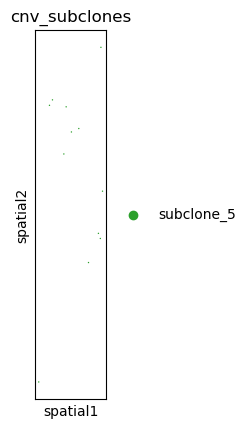

In [15]:
sc.pl.spatial(
    adata[
        (adata.obs['cnv_subclones'] == 'subclone_5') &
        (adata.obs['sample'] == '1105_BL')
    ],
    color='cnv_subclones',
    spot_size=20
)

In [ ]:
# Execution
adata = load_essential_adata(file_path)
print(f"Success! Loaded {adata.n_obs} cells and {adata.n_vars} genes.")

In [24]:
adata.obs['cell_type_oct25']

_index
0         Epithelial
1         Epithelial
2         Epithelial
4         Epithelial
5         Epithelial
             ...    
119291       Myeloid
119305    Adipocytes
119313       B_cells
119315       B_cells
119333       Myeloid
Name: cell_type_oct25, Length: 72345, dtype: category
Categories (9, object): ['Adipocytes', 'B_cells', 'Endothelial', 'Epithelial', ..., 'Myeloid', 'PVLs', 'Plasma', 'T_cells']

In [25]:
adata

AnnData object with n_obs × n_vars = 72345 × 5090
    obs: '_index', 'cell.id', 'cell_area', 'cell_id', 'cell_labels', 'cell_type_oct25', 'cnv_leiden_res0.1', 'cnv_leiden_res0.3', 'cnv_status', 'cnv_subclones', 'compartment', 'control_codeword_counts', 'control_probe_counts', 'deprecated_codeword_counts', 'genomic_control_counts', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'n_counts', 'n_genes_by_counts', 'nucleus_area', 'nucleus_count', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'region', 'sample', 'segmentation_method', 'total_counts', 'transcript_counts', 'unassigned_codeword_counts', 'z_level'
    var: '_index', 'end', 'ensg', 'gene_id', 'log1p_mean_counts', 'log1p_total_counts', 'mean_counts', 'n_cells', 'n_cells_by_counts', 'pct_dropout_by_counts', 'start', 'symbol', 'total_counts'
    obsm: 'spatial'

/var/folders/lb/tq1039w51810g_ckbdgcz42m0000gn/T/ipykernel_8219/1108523726.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color='cell_type_oct25',spot_size=20)


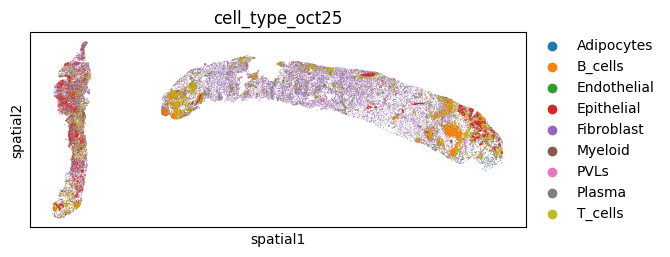

/var/folders/lb/tq1039w51810g_ckbdgcz42m0000gn/T/ipykernel_8219/1108523726.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata,color='sample',spot_size=20)


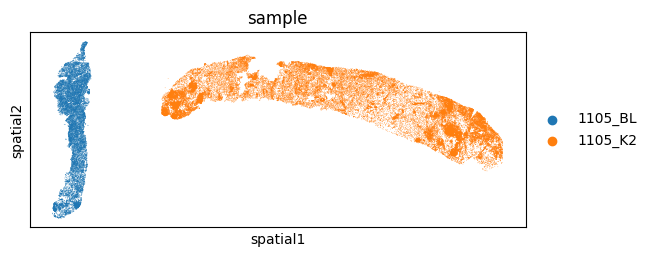

In [33]:
sc.pl.spatial(adata,color='cell_type_oct25',spot_size=20)
sc.pl.spatial(adata,color='sample',spot_size=20)

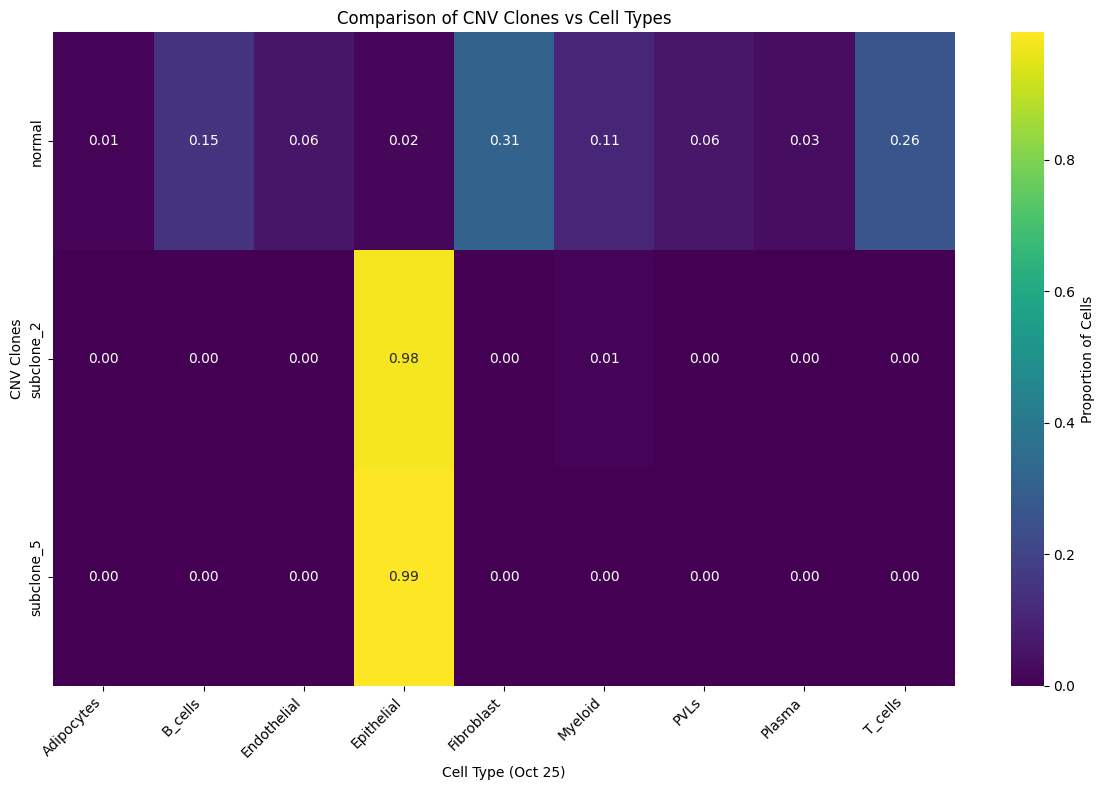

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract the relevant observation data
df = adata.obs[['cnv_subclones', 'cell_type_oct25']]

# 2. Create the Crosstab (Counts)
# This shows the raw number of cells for each combination
ct_counts = pd.crosstab(df['cnv_subclones'], df['cell_type_oct25'])
ct_counts.to_csv('crosstab_counts.csv')

# 3. Create a Normalized Crosstab (Proportions)
# Normalizing by index (row) shows the percentage of each cell type within a clone
ct_norm = pd.crosstab(df['cnv_subclones'], df['cell_type_oct25'], normalize='index')

# 4. Visualization: Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(ct_norm, annot=True, cmap='viridis', fmt='.2f', cbar_kws={'label': 'Proportion of Cells'})
plt.title('Comparison of CNV Clones vs Cell Types')
plt.ylabel('CNV Clones')
plt.xlabel('Cell Type (Oct 25)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('cnv_celltype_comparison.png')

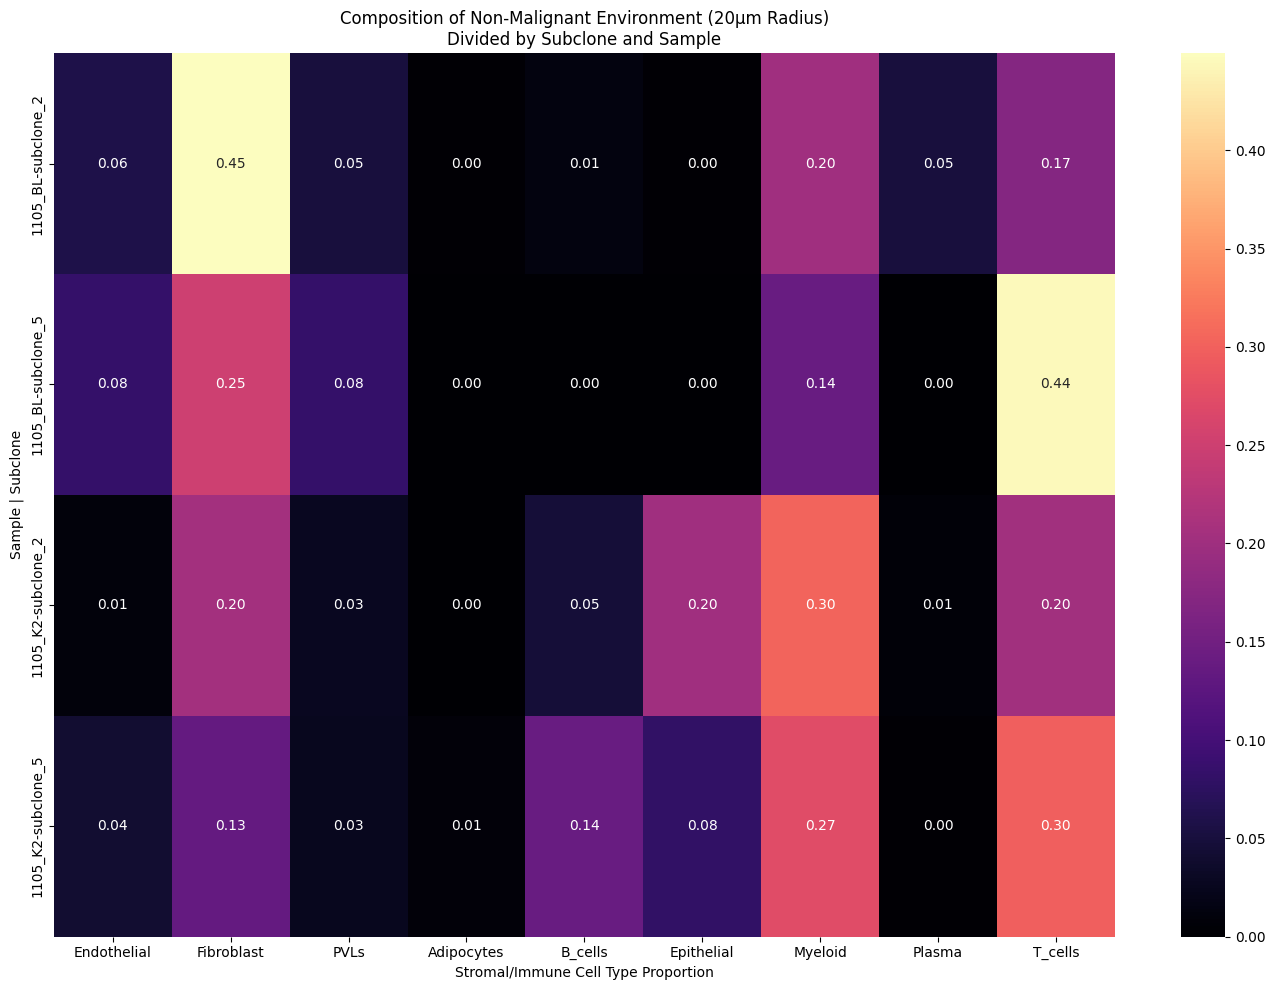

In [36]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# 1. Define the potential cancer cells
cancer_mask = (adata.obs['cell_type_oct25'] == 'Epithelial') & (adata.obs['cnv_subclones'] != 'normal')
adata.obs['is_cancer'] = cancer_mask

results = []
samples = ['1105_BL', '1105_K2']

for sample_id in samples:
    # Subset sample
    s_adata = adata[adata.obs['sample'] == sample_id].copy()
    coords = s_adata.obsm['spatial']
    
    # Identify indices of cancer cells
    # np.where returns a tuple, we take [0] to get the array of indices
    cancer_indices = np.where(s_adata.obs['is_cancer'])[0]
    
    # Check if there are cancer cells in this sample to avoid errors
    if len(cancer_indices) == 0:
        print(f"No cancer cells found in sample {sample_id}")
        continue

    # Indices of "Environment" cells (Non-cancer cells only)
    env_mask = ~s_adata.obs['is_cancer']
    env_indices = np.where(env_mask)[0]
    
    # Build Tree ONLY on the environment cells
    env_tree = KDTree(coords[env_indices])
    
    # Query: Find environment cells within 20um of each cancer cell
    neighbors_in_env = env_tree.query_ball_point(coords[cancer_indices], r=20)
    
    # 2. Calculate composition of the environment
    env_cell_types = s_adata.obs['cell_type_oct25'].values[env_indices]
    subclone_labels = s_adata.obs['cnv_subclones'].values[cancer_indices]
    
    composition_data = []
    for i, neighbor_hits in enumerate(neighbors_in_env):
        # We only care about cells that actually have neighbors within 20um
        if len(neighbor_hits) > 0:
            types = env_cell_types[neighbor_hits]
            counts = pd.Series(types).value_counts(normalize=True)
            counts['cnv_subclones'] = subclone_labels[i]
            counts['sample'] = sample_id
            composition_data.append(counts)
            
    if composition_data:
        sample_df = pd.DataFrame(composition_data).fillna(0)
        # Average the environment composition per subclone
        avg_composition = sample_df.groupby(['sample', 'cnv_subclones']).mean()
        results.append(avg_composition)

# 3. Final Visualization
if results:
    final_df = pd.concat(results)
    
    plt.figure(figsize=(14, 10))
    sns.heatmap(final_df, annot=True, cmap='magma', fmt='.2f')
    plt.title('Composition of Non-Malignant Environment (20μm Radius)\nDivided by Subclone and Sample')
    plt.ylabel('Sample | Subclone')
    plt.xlabel('Stromal/Immune Cell Type Proportion')
    plt.tight_layout()
    plt.show()
else:
    print("No spatial neighborhood data found to plot.")

## Tumor-cell nearest-neighbor composition heatmap

This section computes a per-cell spatial niche profile for each malignant epithelial cell by summarizing the cell-type composition of its `k` nearest spatial neighbors within each sample. Tumor cells are then clustered by these per-cell neighbor-composition vectors and visualized in a heatmap.
